# Test Random Bootstrap Compatibility

Verify that the updated odds_ratio_test script produces identical results when using randomized null distributions (run_permulations=False) compared to the original implementation.

This notebook uses the same test cases as the original but with updated parameter names:
- `alternative="less"` → `alternative="LT"`
- `alternative="greater"` → `alternative="RT"`
- `run_permulations=False` to use original randomized bootstrap

## Setup

In [18]:
import os
import sys

# Make src importable whether cwd is repo root or scripts/
cwd = os.getcwd()
if os.path.basename(cwd) == "scripts":
    repo_root = os.path.abspath(os.path.join(cwd, ".."))
else:
    repo_root = cwd

src_path = os.path.join(repo_root, "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

print(f"Using src path: {src_path}")

# Import the module from src/
import odds_ratio_test as ort

Using src path: /Users/calvin/orb-selection/src


In [20]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


98 species total, 44 foreground, 54 background

LAUNCHING PERMUTATION TEST

** Maximum occupancy set to 95 **

** Minimum occupancy set to 50 **

Counting permuted distributions in which statistics
derived from randomly assigned test groups are SMALLER
than the true distribution's statistics (left-tailed)...



100%|██████████| 10000/10000 [05:13<00:00, 31.86it/s]



Permutation counter for MEAN: 0
Permutation counter for STD DEV: 10000
Permutation counter for SKEW: 8113

Filtering log odds ratio results df for occupancy >= 50, <= 95
and log odds ratio threshold [-1.3627994   1.37019336]

Filtering for presence of Uloborus_diversus

*********************** RESULTS ***********************

Permutation test with 10000 repetitions for loss (left-tailed)
with minimum occupancy *50* and maximum occupancy *95* 
Analysis run on 2026-03-19 at 17:24:50
Foreground list: /Users/calvin/orb-selection/assets/orbweavers-list.txt
Gene count file: /Users/calvin/orb-selection/assets/N5.GeneCount.tsv
Hierarchical orthogroup file: /Users/calvin/orb-selection/assets/N5.tsv

Total number of HOGs in node: 107986
Total number of HOGs within occupancy threshold: 5269
Total species: 98
Foreground count: 44
Background count: 54
True mean: -0.6503994164568763
True standard deviation: 1.5251594203369667
True skew: 0.20218325296976208

** PERMUTATION P-VALUES ** 

Probability 

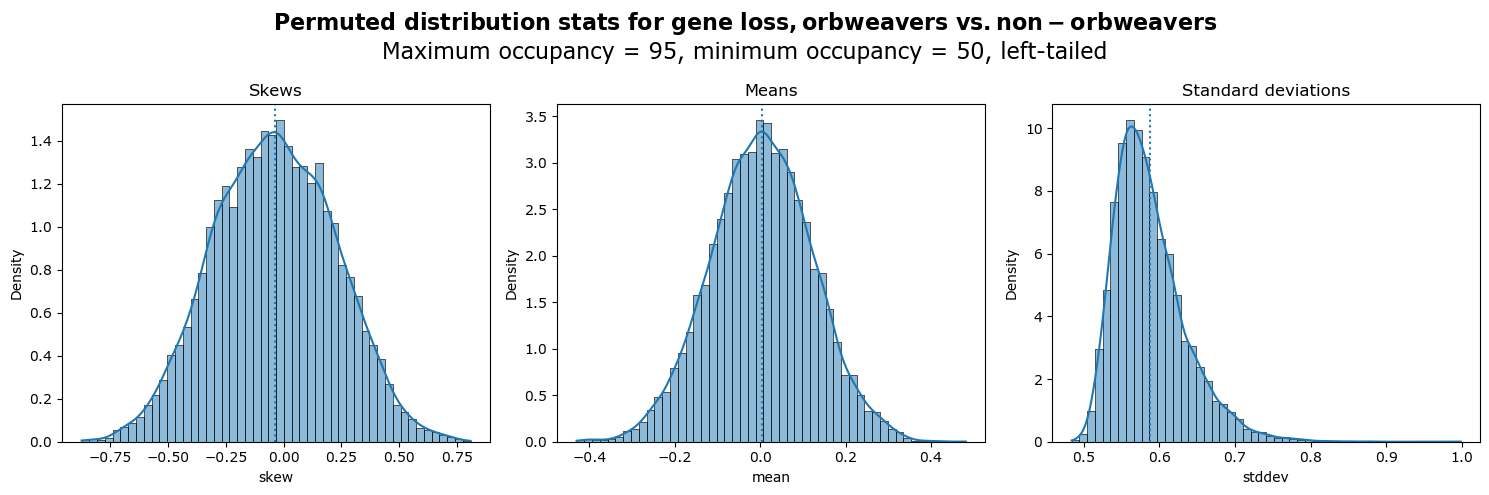

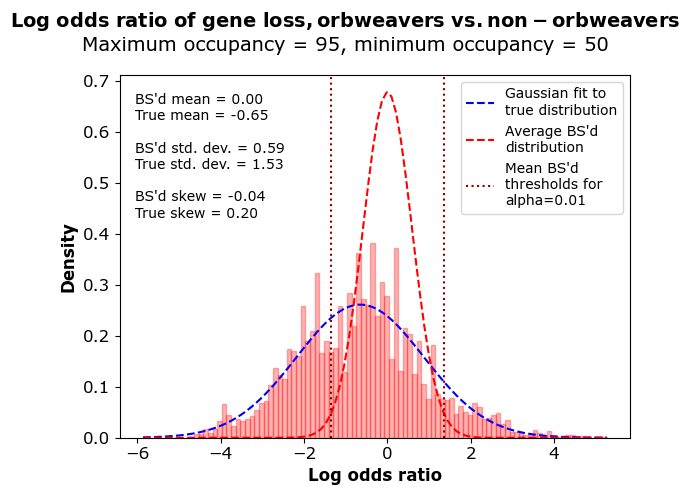

In [22]:
loss_lt_50_95 = ort.odds_ratio_test(
    test="loss",
    occupancy_threshold=50,
    max_occ=95,
    alpha=0.01,
    alternative="LT",
    run_permulations=False,  # Use original randomized bootstrap
    species_of_interest="Uloborus_diversus",
    results_dir=f"~/kelvin-scratch/random_bootstrap_test/",
    fg_name='orbweavers',
    bg_name='non-orbweavers'
)

## Test new version: Loss, Left-Tailed (occupancy 50-95)

`run_permulations=True`

In [37]:
%reload_ext autoreload

In [38]:
loss_lt_50_95 = ort.odds_ratio_test(
    test="loss",
    occupancy_threshold=50,
    max_occ=95,
    alpha=0.01,
    alternative="LT",
    species_of_interest="Uloborus_diversus",
    results_dir=f"~/kelvin-scratch/random_bootstrap_test/",
    fg_name='orbweavers',
    bg_name='non-orbweavers',
    permulations_rdata="~/orb-selection/assets/perms.RData",
)

98 species total, 44 foreground, 54 background


ValueError: Permulation entry 1 in 'testCatPerms' is missing tip names.